In [1]:
import os
import torch
import numpy as np
from tqdm import tqdm
import pandas as pd
from pyaml_env import parse_config, BaseConfig
from my_utils.alignment import compute_RSA, compute_RDM
from safetensors.torch import save_file, load_file
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
config = BaseConfig(parse_config('../config.yaml'))
device = torch.device(f"cuda:{config.device_id}" if torch.cuda.is_available() else "cpu")
data_dir = config.imagenet_val
prune_method = config.prune_method
alignment_metric = config.alignment_metric
if alignment_metric == 'rsa':
    compute_alignment = compute_RSA
alignment_distance = config.alignment_distance
alignment_correlation = config.alignment_correlation

prune_all = config.prune_all # whether to prune all layers or a single layer
dataset_size = config.dataset_size

In [3]:
cache_path = config.project_path + '/activations_cache/'
target_suffix = 'all' if prune_all else 'single'

def load_model_activations(model_name, prune_method):
    # check if activations cache file exists, if so load and return it
    file_name = f"{model_name}_acts_{prune_method}_{target_suffix}.safetensors"
    if os.path.isfile(f"{cache_path}{file_name}"):
        print(f"Loading cached activations from {cache_path}{file_name}.")
        cache = load_file(f"{cache_path}{file_name}")
        acts_cache = {float(k): tensor.numpy() for k, tensor in cache.items()}
        return acts_cache
    else:
        print(f"No cache file found at {cache_path}{file_name}. Computing activation.")
        return None
    

### Compute and Save RSA cross alignment results

In [6]:
sparsity_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

prune_method_1 = "amp"
prune_method_2 = "svd"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed1"

#need to try diff pruning methods for same model (seed1_rand, seed1_amp & seed1_amp & seed1_svd)


model1_acts = load_model_activations(model1_name, prune_method_1)
model2_acts = load_model_activations(model2_name, prune_method_2)


rsa_matrix = np.zeros((len(sparsity_levels), len(sparsity_levels)))


for ki_1, k1 in enumerate(sparsity_levels):
    pruned_acts1 = model1_acts[k1]

    for ki_2, k2 in enumerate(sparsity_levels):
        pruned_acts2 = model2_acts[k2]

        alignment_score = compute_alignment(pruned_acts1, pruned_acts2, dist_metric=alignment_distance, corr_metric=alignment_correlation)
        rsa_matrix[ki_1, ki_2] = alignment_score

        print(f"Computed alignment for sparsity levels {k1} and {k2}: {alignment_score}")
              

# save rsa_matrix to csv 
rsa_df = pd.DataFrame(rsa_matrix, index=sparsity_levels, columns=sparsity_levels)
rsa_df.to_csv(f"{config.project_path}/3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv")


Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_amp_all.safetensors.
Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_svd_all.safetensors.
Computed alignment for sparsity levels 0.1 and 0.1: 0.06866933781394517
Computed alignment for sparsity levels 0.1 and 0.2: 0.4255855505434955
Computed alignment for sparsity levels 0.1 and 0.3: 0.11505420136282765
Computed alignment for sparsity levels 0.1 and 0.4: 0.1240145904247473
Computed alignment for sparsity levels 0.1 and 0.5: 0.129958718836239
Computed alignment for sparsity levels 0.1 and 0.6: 0.14004837625394465
Computed alignment for sparsity levels 0.1 and 0.7: 0.12850119072237215
Computed alignment for sparsity levels 0.1 and 0.8: 0.12843264043751312
Computed alignment for sparsity levels 0.1 and 0.9: 0.125618528953189
Computed alignment for sparsity levels 0.1 and 1: 0.1220843437467163
Computed alignment for sparsity levels 0.2 

##### Self alignment

In [4]:
sparsity_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

prune_method_1 = "random"
prune_method_2 = "random"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed2"

#need to try diff pruning methods for same model (seed1_rand, seed1_amp & seed1_amp & seed1_svd)


model1_acts = load_model_activations(model1_name, prune_method_1)
model2_acts = load_model_activations(model2_name, prune_method_2)


self_rsa_matrix1 = np.zeros((len(sparsity_levels), 1))
self_rsa_matrix2 = np.zeros((len(sparsity_levels), 1))


for ki_1, k1 in enumerate(sparsity_levels):
    full_acts1 = model1_acts[1.0]
    pruned_acts1 = model1_acts[k1]
    self1_alignment_score = compute_alignment(full_acts1, pruned_acts1, dist_metric=alignment_distance, corr_metric=alignment_correlation)
    self_rsa_matrix1[ki_1, 0] = self1_alignment_score

print("Self-alignment for model 1 complete")

for ki_2, k2 in enumerate(sparsity_levels):
    full_acts2 = model2_acts[1.0]
    pruned_acts2 = model2_acts[k2]
    self2_alignment_score = compute_alignment(full_acts2, pruned_acts2, dist_metric=alignment_distance, corr_metric=alignment_correlation)
    self_rsa_matrix2[ki_2, 0] = self2_alignment_score

print("Self-alignment for model 2 complete")
              

# save rsa_matrix to csv 
self_rsa_df1 = pd.DataFrame(self_rsa_matrix1, index=sparsity_levels)
self_rsa_df2 = pd.DataFrame(self_rsa_matrix2, index=sparsity_levels)
self_rsa_df1.to_csv(f"{config.project_path}/3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_self.csv")
self_rsa_df2.to_csv(f"{config.project_path}/3_cross_alignment/results/rsa_matrix_{model2_name}_{prune_method_2}_self.csv")


Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_random_all.safetensors.
Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed2_acts_random_all.safetensors.
Self-alignment for model 1 complete
Self-alignment for model 2 complete


### Visualise cross-alignment results

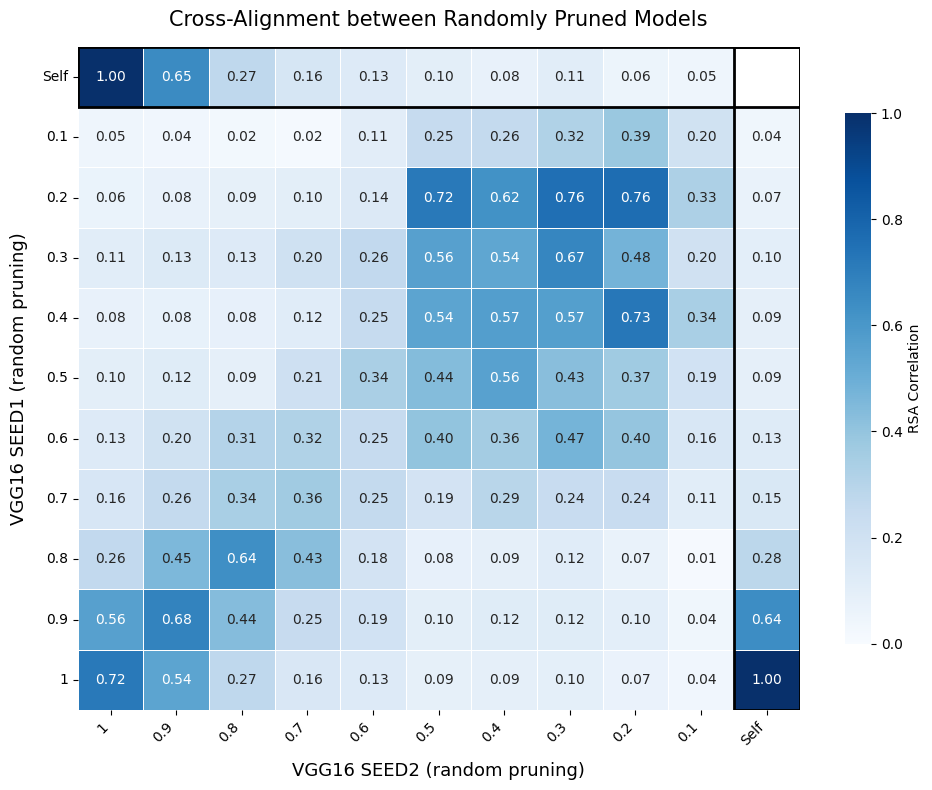

In [66]:
prune_method_1 = "random"
prune_method_2 = "random"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed2"



csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv'

rsa_df = pd.read_csv(csv_path, index_col=0)

self1_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_self.csv'
self2_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model2_name}_{prune_method_2}_self.csv'

rsa_self_df1 = pd.read_csv(self1_csv_path, index_col=0)
rsa_self_df2 = pd.read_csv(self2_csv_path, index_col=0)


# add self-alignment scores as additional col and row in rsa_df
num_k = len(sparsity_levels)
rsa_full_matrix = np.zeros((num_k + 1, num_k + 1))
rsa_full_matrix[1:num_k+1, 1:num_k+1] = rsa_df.values
rsa_full_matrix[0, 1:num_k+1] = rsa_self_df1.values.flatten()
rsa_full_matrix[1:num_k+1, 0] = rsa_self_df2.values.flatten()
rsa_full_matrix[0, 0] = np.nan


sparsity_levels_labels = ['Self'] + sparsity_levels.copy()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    rsa_full_matrix,
    ax=ax,
    cmap="Blues",               # Blue colormap
    annot=True,                 # Show correlation values in each cell
    fmt=".2f",                  # Format to 2 decimal places
    vmin=0, vmax=1,             # Correlation range (adjust if needed)
    linewidths=0.5,             # Grid lines between cells
    linecolor="white",
    cbar_kws={
        "label": "RSA Correlation",
        "shrink": 0.8
    }
)

# Axis labels
ax.set_xlabel(f"{model2_name.replace('_', ' ').upper()} ({prune_method_2} pruning)", fontsize=13, labelpad=10)
ax.set_ylabel(f"{model1_name.replace('_', ' ').upper()} ({prune_method_1} pruning)", fontsize=13, labelpad=10)
ax.set_title(f"Cross-Alignment between Randomly Pruned Models", fontsize=15, pad=15)
ax.set_xticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_yticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_xticklabels(sparsity_levels_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(sparsity_levels_labels, rotation=0, fontsize=10)
#invert x and y axes
ax.invert_xaxis()

border_kwargs = dict(linewidth=2, edgecolor="black", facecolor="none")

#self row and col gets highlighted
n=len(sparsity_levels_labels)
ax.add_patch(patches.Rectangle((0, 0), n, 1, **border_kwargs))
ax.add_patch(patches.Rectangle((0, 0), 1, n, **border_kwargs))

# Rotate tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

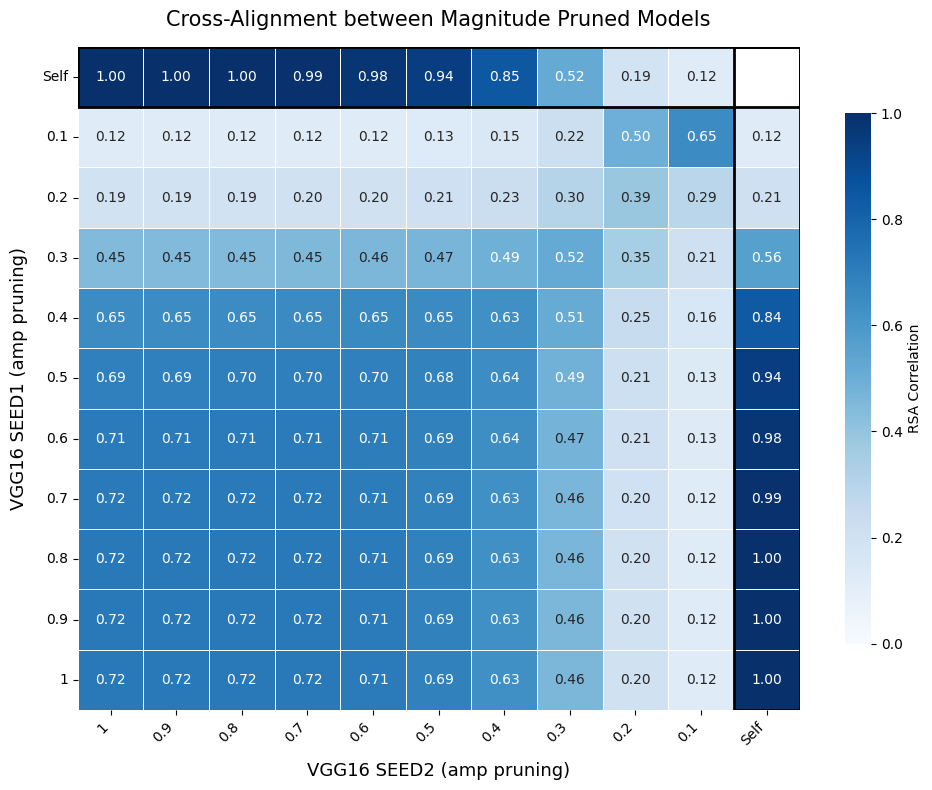

In [67]:
prune_method_1 = "amp"
prune_method_2 = "amp"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed2"

csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv'

rsa_df = pd.read_csv(csv_path, index_col=0)

self1_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_self.csv'
self2_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model2_name}_{prune_method_2}_self.csv'

rsa_self_df1 = pd.read_csv(self1_csv_path, index_col=0)
rsa_self_df2 = pd.read_csv(self2_csv_path, index_col=0)


# add self-alignment scores as additional col and row in rsa_df
num_k = len(sparsity_levels)
rsa_full_matrix = np.zeros((num_k + 1, num_k + 1))
rsa_full_matrix[1:num_k+1, 1:num_k+1] = rsa_df.values
rsa_full_matrix[0, 1:num_k+1] = rsa_self_df1.values.flatten()
rsa_full_matrix[1:num_k+1, 0] = rsa_self_df2.values.flatten()
rsa_full_matrix[0, 0] = np.nan


sparsity_levels_labels = ['Self'] + sparsity_levels.copy()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    rsa_full_matrix,
    ax=ax,
    cmap="Blues",               # Blue colormap
    annot=True,                 # Show correlation values in each cell
    fmt=".2f",                  # Format to 2 decimal places
    vmin=0, vmax=1,             # Correlation range (adjust if needed)
    linewidths=0.5,             # Grid lines between cells
    linecolor="white",
    cbar_kws={
        "label": "RSA Correlation",
        "shrink": 0.8
    }
)

# Axis labels
ax.set_xlabel(f"{model2_name.replace('_', ' ').upper()} ({prune_method_2} pruning)", fontsize=13, labelpad=10)
ax.set_ylabel(f"{model1_name.replace('_', ' ').upper()} ({prune_method_1} pruning)", fontsize=13, labelpad=10)
ax.set_title(f"Cross-Alignment between Magnitude Pruned Models", fontsize=15, pad=15)
ax.set_xticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_yticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_xticklabels(sparsity_levels_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(sparsity_levels_labels, rotation=0, fontsize=10)
#invert x and y axes
ax.invert_xaxis()

border_kwargs = dict(linewidth=2, edgecolor="black", facecolor="none")

#self row and col gets highlighted
n=len(sparsity_levels_labels)
ax.add_patch(patches.Rectangle((0, 0), n, 1, **border_kwargs))
ax.add_patch(patches.Rectangle((0, 0), 1, n, **border_kwargs))

# Rotate tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

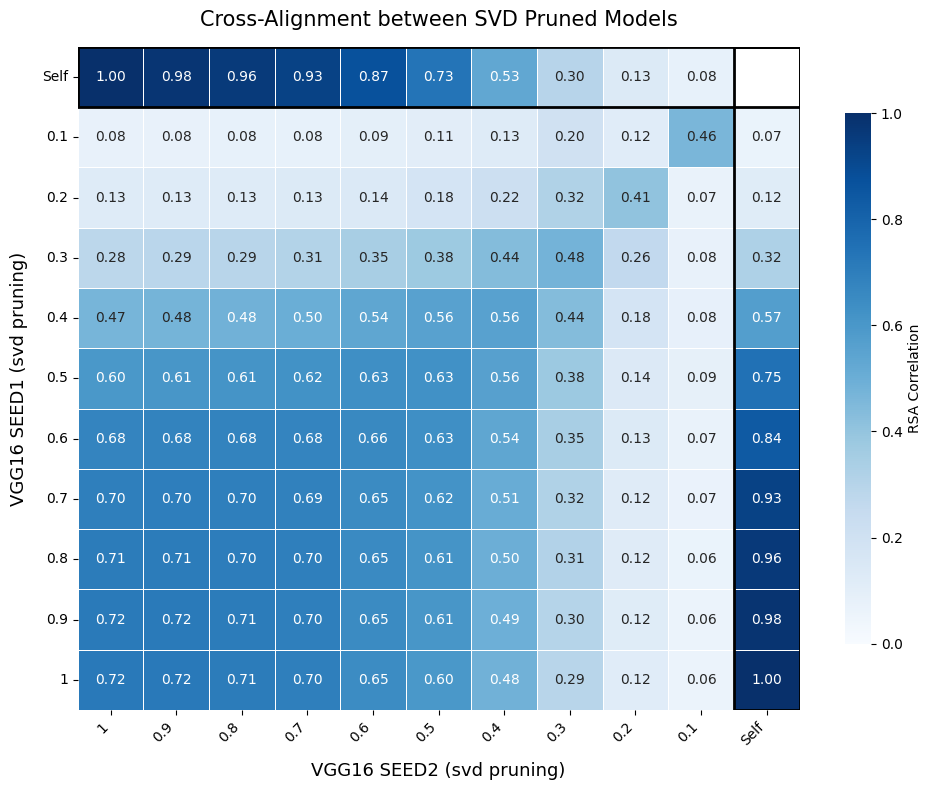

In [68]:
prune_method_1 = "svd"
prune_method_2 = "svd"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed2"

csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv'

rsa_df = pd.read_csv(csv_path, index_col=0)

self1_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_self.csv'
self2_csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model2_name}_{prune_method_2}_self.csv'

rsa_self_df1 = pd.read_csv(self1_csv_path, index_col=0)
rsa_self_df2 = pd.read_csv(self2_csv_path, index_col=0)


# add self-alignment scores as additional col and row in rsa_df
num_k = len(sparsity_levels)
rsa_full_matrix = np.zeros((num_k + 1, num_k + 1))
rsa_full_matrix[1:num_k+1, 1:num_k+1] = rsa_df.values
rsa_full_matrix[0, 1:num_k+1] = rsa_self_df1.values.flatten()
rsa_full_matrix[1:num_k+1, 0] = rsa_self_df2.values.flatten()
rsa_full_matrix[0, 0] = np.nan


sparsity_levels_labels = ['Self'] + sparsity_levels.copy()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    rsa_full_matrix,
    ax=ax,
    cmap="Blues",               # Blue colormap
    annot=True,                 # Show correlation values in each cell
    fmt=".2f",                  # Format to 2 decimal places
    vmin=0, vmax=1,             # Correlation range (adjust if needed)
    linewidths=0.5,             # Grid lines between cells
    linecolor="white",
    cbar_kws={
        "label": "RSA Correlation",
        "shrink": 0.8
    }
)

# Axis labels
ax.set_xlabel(f"{model2_name.replace('_', ' ').upper()} ({prune_method_2} pruning)", fontsize=13, labelpad=10)
ax.set_ylabel(f"{model1_name.replace('_', ' ').upper()} ({prune_method_1} pruning)", fontsize=13, labelpad=10)
ax.set_title(f"Cross-Alignment between SVD Pruned Models", fontsize=15, pad=15)
ax.set_xticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_yticks(np.arange(len(sparsity_levels_labels)) + 0.5)
ax.set_xticklabels(sparsity_levels_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(sparsity_levels_labels, rotation=0, fontsize=10)
#invert x and y axes
ax.invert_xaxis()

border_kwargs = dict(linewidth=2, edgecolor="black", facecolor="none")

#self row and col gets highlighted
n=len(sparsity_levels_labels)
ax.add_patch(patches.Rectangle((0, 0), n, 1, **border_kwargs))
ax.add_patch(patches.Rectangle((0, 0), 1, n, **border_kwargs))

# Rotate tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

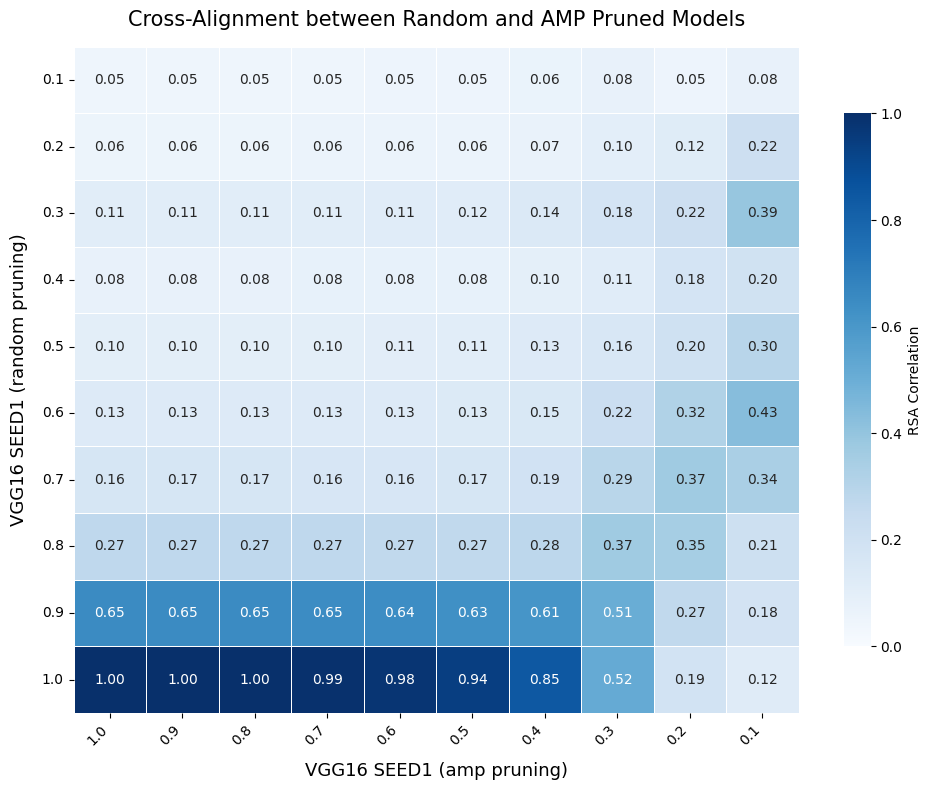

In [17]:
prune_method_1 = "random"
prune_method_2 = "amp"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed1"

csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv'

rsa_df = pd.read_csv(csv_path, index_col=0)


fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    rsa_df,
    ax=ax,
    cmap="Blues",               # Blue colormap
    annot=True,                 # Show correlation values in each cell
    fmt=".2f",                  # Format to 2 decimal places
    vmin=0, vmax=1,             # Correlation range (adjust if needed)
    linewidths=0.5,             # Grid lines between cells
    linecolor="white",
    cbar_kws={
        "label": "RSA Correlation",
        "shrink": 0.8
    }
)

# Axis labels
ax.set_xlabel(f"{model2_name.replace('_', ' ').upper()} ({prune_method_2} pruning)", fontsize=13, labelpad=10)
ax.set_ylabel(f"{model1_name.replace('_', ' ').upper()} ({prune_method_1} pruning)", fontsize=13, labelpad=10)
ax.set_title(f"Cross-Alignment between Random and AMP Pruned Models", fontsize=15, pad=15)
ax.invert_xaxis()

# Rotate tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

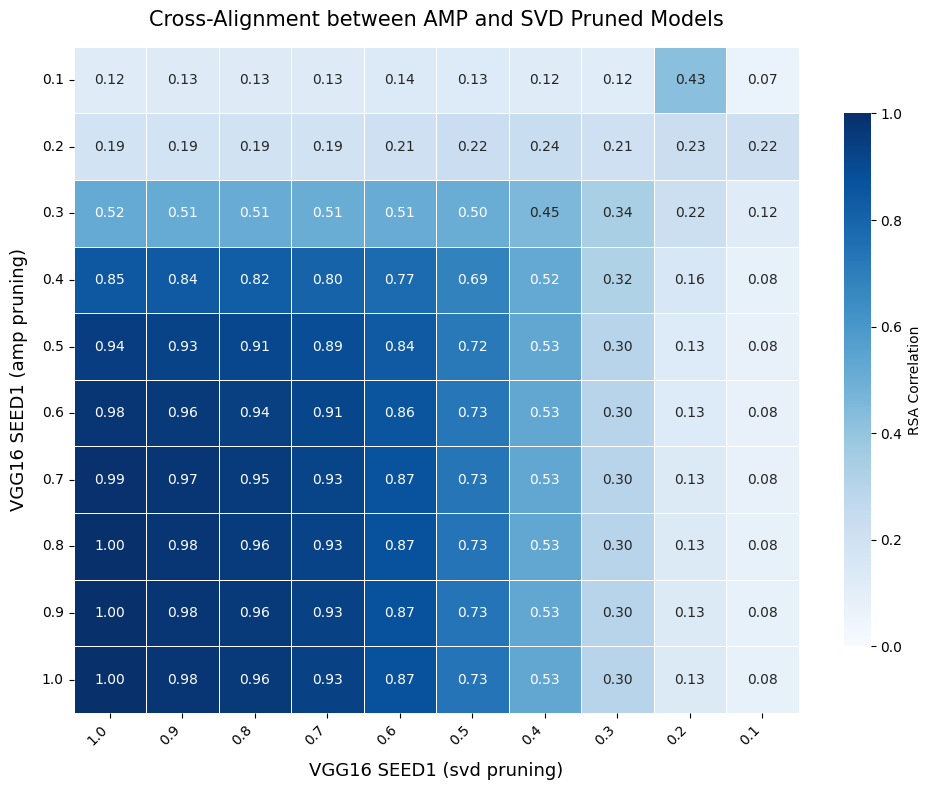

In [18]:
prune_method_1 = "amp"
prune_method_2 = "svd"
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed1"

csv_path = f'{config.project_path}3_cross_alignment/results/rsa_matrix_{model1_name}_{prune_method_1}_{model2_name}_{prune_method_2}.csv'

rsa_df = pd.read_csv(csv_path, index_col=0)


fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    rsa_df,
    ax=ax,
    cmap="Blues",               # Blue colormap
    annot=True,                 # Show correlation values in each cell
    fmt=".2f",                  # Format to 2 decimal places
    vmin=0, vmax=1,             # Correlation range (adjust if needed)
    linewidths=0.5,             # Grid lines between cells
    linecolor="white",
    cbar_kws={
        "label": "RSA Correlation",
        "shrink": 0.8
    }
)

# Axis labels
ax.set_xlabel(f"{model2_name.replace('_', ' ').upper()} ({prune_method_2} pruning)", fontsize=13, labelpad=10)
ax.set_ylabel(f"{model1_name.replace('_', ' ').upper()} ({prune_method_1} pruning)", fontsize=13, labelpad=10)
ax.set_title(f"Cross-Alignment between AMP and SVD Pruned Models", fontsize=15, pad=15)
ax.invert_xaxis()

# Rotate tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

## Comparing RDMs

RDM Diff correlations with the same model being pruned

Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_amp_all.safetensors.
Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_amp_all.safetensors.


/tmp/ipykernel_1601569/3273218313.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_1601569/3273218313.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


Text(0.5, 1.02, 'VGGA vs. VGGA - AMP ')

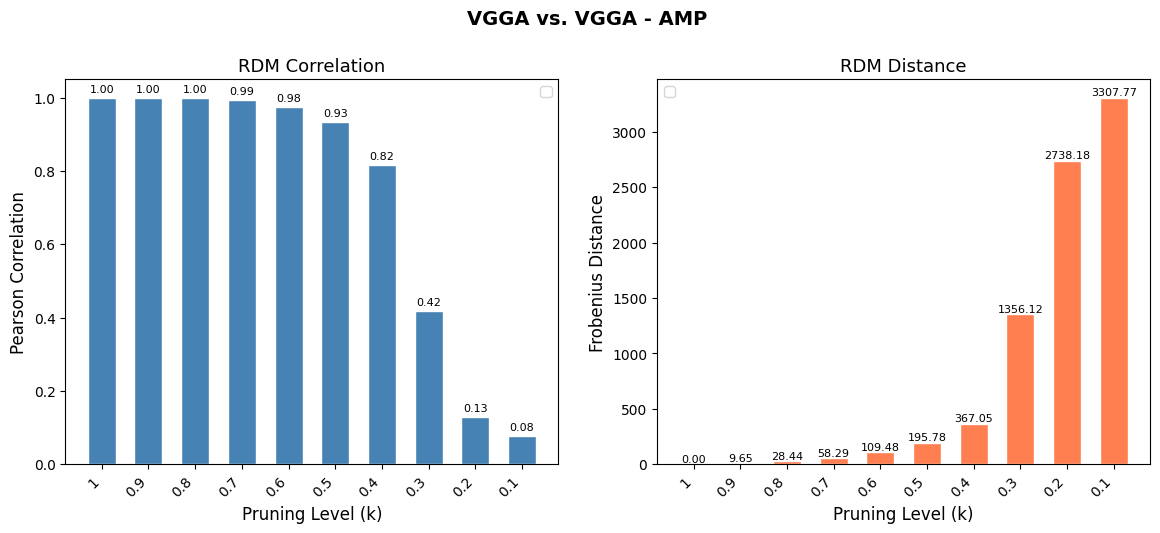

In [31]:
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed1"
prune_method_1 = "amp"
prune_method_2 = "amp"
prune_k_1 = 1
prune_k_2 = 0.1

prune_k_2_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
rdm_correlations = []
rdm_distances = []

acts1  = load_model_activations(model1_name, prune_method_1)
acts2 = load_model_activations(model2_name, prune_method_2)



rdm1 = compute_RDM(acts1[prune_k_1], dist_metric=alignment_distance, bounded=True)
rdm1_flat = rdm1[np.triu_indices(rdm1.shape[0], k=1)]

for ki_2, k_2 in enumerate(prune_k_2_vals):
    rdm2 = compute_RDM(acts2[k_2], dist_metric=alignment_distance, bounded=True)
    rdm2_flat = rdm2[np.triu_indices(rdm2.shape[0], k=1)]

    rdm_corr = np.corrcoef(rdm1_flat, rdm2_flat)[0, 1]
    rdm_dist = np.linalg.norm(rdm1_flat - rdm2_flat)
    rdm_correlations.append(rdm_corr)
    rdm_distances.append(rdm_dist)


x = np.arange(len(prune_k_2_vals))
x_labels = [str(k) for k in prune_k_2_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: RDM Correlation ---
bars1 = axes[0].bar(x, rdm_correlations, color="steelblue", edgecolor="white", width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Pruning Level (k)", fontsize=12)
axes[0].set_ylabel("Pearson Correlation", fontsize=12)
axes[0].set_title(f"RDM Correlation", fontsize=13)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].invert_xaxis()
for bar, val in zip(bars1, rdm_correlations):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# --- Plot 2: RDM Frobenius Distance ---
bars2 = axes[1].bar(x, rdm_distances, color="coral", edgecolor="white", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Pruning Level (k)", fontsize=12)
axes[1].set_ylabel("Frobenius Distance", fontsize=12)
axes[1].set_title(f"RDM Distance", fontsize=13)
axes[1].legend()
axes[1].invert_xaxis()
for bar, val in zip(bars2, rdm_distances):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    
modelnames = {
    "vgg16_seed1": "VGGA",
    "vgg16_seed2": "VGG16B"
}
plt.suptitle(f"{modelnames[model1_name]} vs. {modelnames[model2_name]} - {prune_method_2.upper()} ", fontsize=14, fontweight="bold", y=1.02)




Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed1_acts_amp_all.safetensors.
Loading cached activations from /home/nirajesh/sparsity_alignment//activations_cache/vgg16_seed2_acts_amp_all.safetensors.


/tmp/ipykernel_1601569/4154746065.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_1601569/4154746065.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


Text(0.5, 1.02, 'VGGA vs. VGG16B - AMP ')

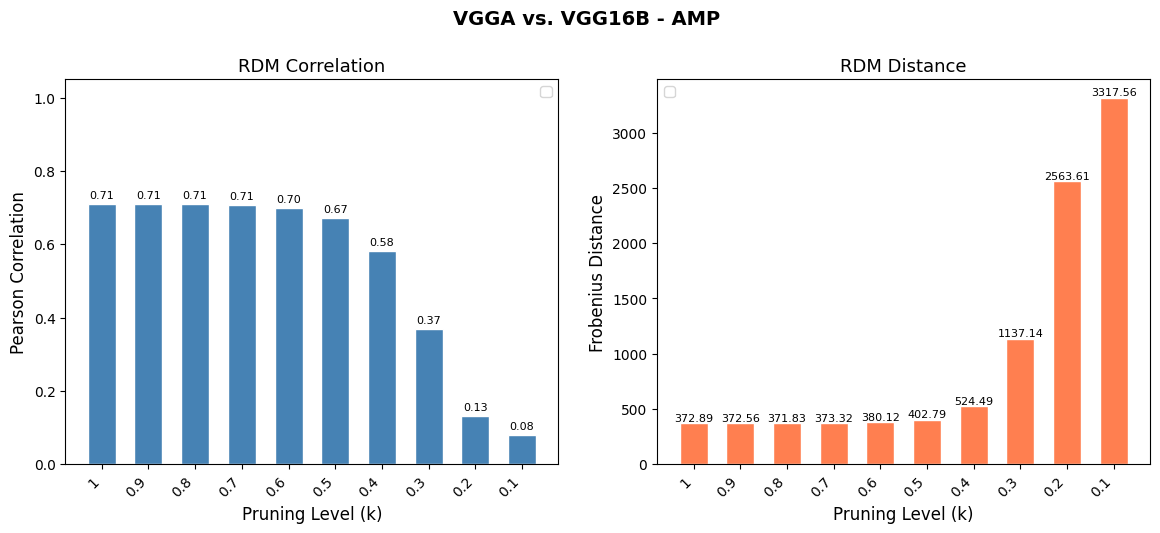

In [32]:
model1_name = "vgg16_seed1"
model2_name = "vgg16_seed2"
prune_method_1 = "amp"
prune_method_2 = "amp"
prune_k_1 = 1
prune_k_2_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
rdm_correlations = []
rdm_distances = []

acts1  = load_model_activations(model1_name, prune_method_1)
acts2 = load_model_activations(model2_name, prune_method_2)



rdm1 = compute_RDM(acts1[prune_k_1], dist_metric=alignment_distance, bounded=True)
rdm1_flat = rdm1[np.triu_indices(rdm1.shape[0], k=1)]

for ki_2, k_2 in enumerate(prune_k_2_vals):
    rdm2 = compute_RDM(acts2[k_2], dist_metric=alignment_distance, bounded=True)
    rdm2_flat = rdm2[np.triu_indices(rdm2.shape[0], k=1)]

    rdm_corr = np.corrcoef(rdm1_flat, rdm2_flat)[0, 1]
    rdm_dist = np.linalg.norm(rdm1_flat - rdm2_flat)
    rdm_correlations.append(rdm_corr)
    rdm_distances.append(rdm_dist)


x = np.arange(len(prune_k_2_vals))
x_labels = [str(k) for k in prune_k_2_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: RDM Correlation ---
bars1 = axes[0].bar(x, rdm_correlations, color="steelblue", edgecolor="white", width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Pruning Level (k)", fontsize=12)
axes[0].set_ylabel("Pearson Correlation", fontsize=12)
axes[0].set_title(f"RDM Correlation", fontsize=13)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].invert_xaxis()
for bar, val in zip(bars1, rdm_correlations):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# --- Plot 2: RDM Frobenius Distance ---
bars2 = axes[1].bar(x, rdm_distances, color="coral", edgecolor="white", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Pruning Level (k)", fontsize=12)
axes[1].set_ylabel("Frobenius Distance", fontsize=12)
axes[1].set_title(f"RDM Distance", fontsize=13)
axes[1].legend()
axes[1].invert_xaxis()
for bar, val in zip(bars2, rdm_distances):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    
modelnames = {
    "vgg16_seed1": "VGGA",
    "vgg16_seed2": "VGG16B"
}
plt.suptitle(f"{modelnames[model1_name]} vs. {modelnames[model2_name]} - {prune_method_2.upper()} ", fontsize=14, fontweight="bold", y=1.02)


